In [135]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import glob


from redpitaya_control.redpitaya_dev import redpitaya_dev
from redpitaya_control.event_logger import EventLogger, unpack, load_run, fit_clock, counter_to_unix
from redpitaya_control import compute_coeff


import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

from scipy.optimize import curve_fit
from scipy.special import factorial


from pathlib import Path
import matplotlib.pyplot as plt





MAX_Q15 = 32767 / 32768


In [136]:



def adu_to_kev(adu):

    a = -2.555374e-08
    b = 1.015411e-02
    c = 1.830826e+00
    
    return a * (adu ** 2) + b * adu + c


def kev_to_adu(kev):
    a = -2.555374e-08
    b = 1.015411e-02
    c = 1.830826e+00
    
    # Calculate ADU using the positive root of the quadratic formula
    adu = (-b + np.sqrt(b**2 - 4 * a * (c - kev))) / (2 * a)
    
    return adu


import numpy as np


def debounce_chb(ts_us, chb, min_stint_ms=50):
    """Single-pass vector debouncer that removes noise chatter in O(E) time where

    E is the number of state transitions (edges).
    """
    min_stint_us = min_stint_ms * 1000
    chb_clean = chb.copy()

    # Find transition indices
    edges = np.flatnonzero(np.diff(chb_clean) != 0) + 1
    if len(edges) == 0:
        return chb_clean

    # Define slice boundaries for each continuous segment
    starts = np.concatenate(([0], edges))
    ends = np.concatenate((edges - 1, [len(chb_clean) - 1]))

    # Track active direction state
    active_state = chb_clean[0]

    # Single pass over segment boundaries
    for s_idx, e_idx in zip(starts, ends):
        seg_state = chb_clean[s_idx]
        seg_duration = ts_us[e_idx] - ts_us[s_idx]

        if seg_state != active_state:
            if seg_duration < min_stint_us:
                # Glitch detected: overwrite with the active state
                chb_clean[s_idx : e_idx + 1] = active_state
            else:
                # Valid state change: update active state
                active_state = seg_state

    return chb_clean
    return chb



# def process_all_runs(data_dir="data", rng=None):
    

#     if not os.path.exists(data_dir):
#         print(f"Error: Directory '{data_dir}' does not exist.")
#         return {}

#     # Get all subdirectories in Data
#     folders = [
#         f
#         for f in os.listdir(data_dir)
#         if os.path.isdir(os.path.join(data_dir, f))
#     ]

#     if not folders:
#         print(f"No run folders found inside '{data_dir}'.")
#         return {}

#     results = {}

#     for folder_name in sorted(folders):
        
#         runfile_path = os.path.join(data_dir, folder_name)
#         vel_raw = float(folder_name.split("_")[0])
#         vel = vel_raw / 1000.0 
#         folder_name = f'{vel}'
#         bin_pattern = os.path.join(runfile_path, "events_*.bin")
#         tiepoints_path = os.path.join(runfile_path, "tiepoints.csv")

#         # Check if the required files exist before trying to process
#         if not glob.glob(bin_pattern) or not os.path.exists(tiepoints_path):
#             print(
#                 f"[{folder_name}] Missing events_*.bin or tiepoints.csv. Skipping..."
#             )
#             continue

#         # 1. Load and unpack data
#         raw = load_run(bin_pattern)

#         ts_us, energy, chb = unpack(raw)
#         chb = np.round(chb).astype(int)

#         # Filter positive timestamps and keep energy aligned
#         valid_mask = ts_us > 0
#         ts_us = ts_us[valid_mask]
#         energy = energy[valid_mask]
#         chb = chb[valid_mask]

#         if len(ts_us) > 1:
#             # print(ts_us[-1])
#             # print(ts_us[0])
#             print(
#                 f"[{folder_name}] {len(ts_us)} events, span {(ts_us[-1]-ts_us[0])/1e6:.1f} s"
#             )
#         else:
#             print(f"[{folder_name}] No events found. Skipping...")
#             continue

#         # Clock drift correction
#         a, b, ppm = fit_clock(tiepoints_path)
#         print(f"[{folder_name}] Crystal drift: {ppm:+.1f} ppm")
#         t_unix = counter_to_unix(ts_us, a, b)

#         # 3. Chunk splitting
#         split_indices = np.where(np.diff(chb) != 0)[0] + 1

#         energy_chunks = np.split(energy, split_indices)
#         ts_chunks = np.split(ts_us, split_indices)
#         chb_chunks = np.split(chb, split_indices)

#         chunk_directions = [c[0] for c in chb_chunks]

#         # 4. Group into forward and backward lists
#         forward_energies = [
#             e for e, d in zip(energy_chunks, chunk_directions) if d == 1
#         ]
#         backward_energies = [
#             e for e, d in zip(energy_chunks, chunk_directions) if d == 0
#         ]

#         forward_times = [
#             t for t, d in zip(ts_chunks, chunk_directions) if d == 1
#         ]
#         backward_times = [
#             t for t, d in zip(ts_chunks, chunk_directions) if d == 0
#         ]

#         results[folder_name] = {
#             "runfile": folder_name,
#             "runfile_path": runfile_path,
#             "ts_us": ts_us,
#             "energy": energy,
#             "t_unix": t_unix,
#             "chb": chb,
#             "energy_chunks": energy_chunks,
#             "ts_chunks": ts_chunks,
#             "chunk_directions": np.array(chunk_directions),
#             "forward_energies": forward_energies,
#             "backward_energies": backward_energies,
#             "forward_times": forward_times,
#             "backward_times": backward_times,
#             "velocities": vel,
#         }

#     return results





In [137]:
def process_all_runs(data_dir="data", rng=None, settle_time_ms=50):
    if not os.path.exists(data_dir):
        print(f"Error: Directory '{data_dir}' does not exist.")
        return {}

    folders = [
        f
        for f in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, f))
    ]

    if not folders:
        print(f"No run folders found inside '{data_dir}'.")
        return {}

    settle_time_us = settle_time_ms * 1000  # Convert ms to microseconds
    results = {}

    for folder_name in sorted(folders):
        runfile_path = os.path.join(data_dir, folder_name)

        try:
            vel_raw = float(folder_name.split("_")[0])
            vel = vel_raw / 1000.0
        except ValueError:
            print(f"Skipping '{folder_name}': Invalid folder name format.")
            continue

        run_key = f"{vel}"
        bin_pattern = os.path.join(runfile_path, "events_*.bin")
        tiepoints_path = os.path.join(runfile_path, "tiepoints.csv")

        if not glob.glob(bin_pattern) or not os.path.exists(tiepoints_path):
            print(
                f"[{run_key}] Missing events_*.bin or tiepoints.csv. Skipping..."
            )
            continue

        # 1. Load and unpack data
        raw = load_run(bin_pattern)
        ts_us, energy, chb = unpack(raw)

        chb = debounce_chb(ts_us, chb, min_stint_ms=30)
        # Filter positive timestamps
        valid_mask = ts_us > 0
        ts_us = ts_us[valid_mask]
        energy = energy[valid_mask]
        chb = chb[valid_mask]
            
        if len(ts_us) <= 1:
            print(f"[{run_key}] No events found. Skipping...")
            continue

        print(
            f"[{run_key}] {len(ts_us)} events, span {(ts_us[-1]-ts_us[0])/1e6:.1f} s"
        )

        # Clock drift correction
        a, b, ppm = fit_clock(tiepoints_path)
        print(f"[{run_key}] Crystal drift: {ppm:+.1f} ppm")
        t_unix = counter_to_unix(ts_us, a, b)

        # 2. Chunk splitting
        split_indices = np.where(np.diff(chb) != 0)[0] + 1

        energy_chunks = np.split(energy, split_indices)
        ts_chunks = np.split(ts_us, split_indices)
        chb_chunks = np.split(chb, split_indices)

        chunk_directions = [c[0] for c in chb_chunks]

        # 3. Categorize & trim 50ms transient per stint
        forward_energies, backward_energies = [], []
        forward_times, backward_times = [], []

        forward_energies_trimmed, backward_energies_trimmed = [], []
        forward_times_trimmed, backward_times_trimmed = [], []

        forward_stint_durations, backward_stint_durations = [], []

        for e_chunk, t_chunk, d in zip(
            energy_chunks, ts_chunks, chunk_directions
        ):
            if len(t_chunk) == 0:
                continue

            # Full stint duration in seconds
            stint_duration_s = (t_chunk[-1] - t_chunk[0]) / 1e6

            # Filter out the first 50ms (50,000 microseconds) after switch
            start_us = t_chunk[0]
            trim_mask = t_chunk >= (start_us + settle_time_us)

            e_trimmed = e_chunk[trim_mask]
            t_trimmed = t_chunk[trim_mask]

            if d == 1:  # Forward
                forward_energies.append(e_chunk)
                forward_times.append(t_chunk)
                forward_energies_trimmed.append(e_trimmed)
                forward_times_trimmed.append(t_trimmed)
                forward_stint_durations.append(stint_duration_s)
            else:  # Backward (d == 0)
                backward_energies.append(e_chunk)
                backward_times.append(t_chunk)
                backward_energies_trimmed.append(e_trimmed)
                backward_times_trimmed.append(t_trimmed)
                backward_stint_durations.append(stint_duration_s)

        results[run_key] = {
            "runfile": folder_name,
            "runfile_path": runfile_path,
            "velocities": vel,
            "ts_us": ts_us,
            "energy": energy,
            "t_unix": t_unix,
            "chb": chb,
            "energy_chunks": energy_chunks,
            "ts_chunks": ts_chunks,
            "chunk_directions": np.array(chunk_directions),
            # Raw arrays (untrimmed)
            "forward_energies": forward_energies,
            "backward_energies": backward_energies,
            "forward_times": forward_times,
            "backward_times": backward_times,
            # Trimmed arrays (first 50ms removed)
            "forward_energies_trimmed": forward_energies_trimmed,
            "backward_energies_trimmed": backward_energies_trimmed,
            "forward_times_trimmed": forward_times_trimmed,
            "backward_times_trimmed": backward_times_trimmed,
            # Stint duration lists (in seconds)
            "forward_stint_durations": np.array(forward_stint_durations),
            "backward_stint_durations": np.array(backward_stint_durations),
        }

    return results
processed_runs = process_all_runs(data_dir='data_test')


[0.002] 256792 events, span 300.4 s
[0.002] Crystal drift: -1.8 ppm
[0.004] 257603 events, span 300.6 s
[0.004] Crystal drift: +23.5 ppm
[0.1] 284389 events, span 300.2 s
[0.1] Crystal drift: +0.5 ppm
[0.01] 261856 events, span 300.0 s
[0.01] Crystal drift: +12.9 ppm
[0.02] 271929 events, span 300.7 s
[0.02] Crystal drift: -35.1 ppm
[0.03] 277201 events, span 300.4 s
[0.03] Crystal drift: +6.2 ppm
[0.04] 280199 events, span 300.3 s
[0.04] Crystal drift: -5.1 ppm
[0.05] 282298 events, span 300.7 s
[0.05] Crystal drift: +8.9 ppm
[0.06] 283093 events, span 300.5 s
[0.06] Crystal drift: -3.1 ppm
[0.07] 283896 events, span 300.4 s
[0.07] Crystal drift: +5.2 ppm
[0.08] 285541 events, span 300.8 s
[0.08] Crystal drift: -23.3 ppm
[0.09] 284417 events, span 300.1 s
[0.09] Crystal drift: +14.6 ppm


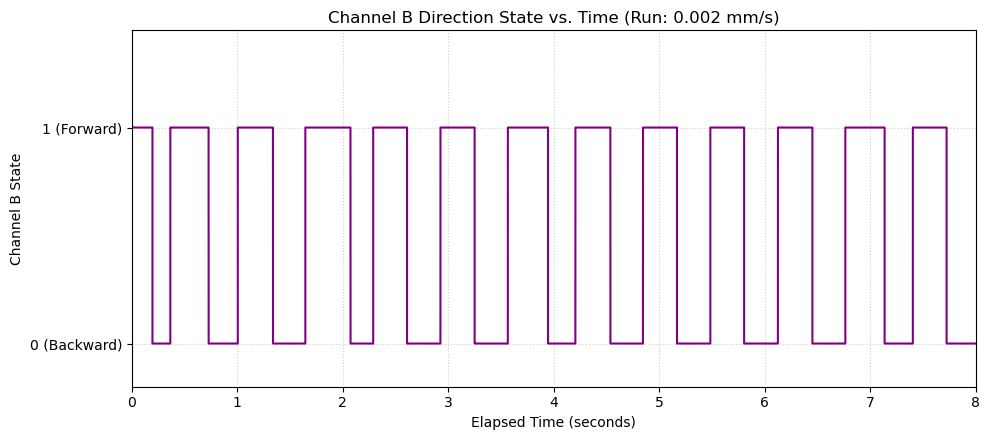

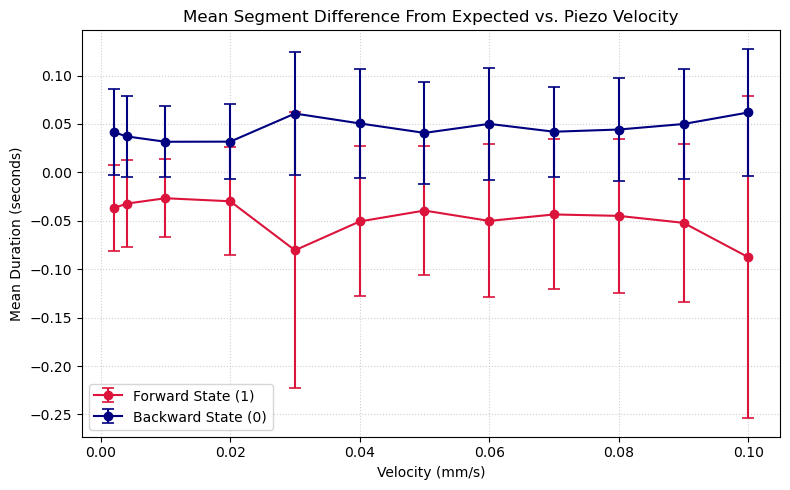

In [143]:
import matplotlib.pyplot as plt
import numpy as np

# Pick a run key from processed_runs
run_key = list(processed_runs.keys())[0]
data = processed_runs[run_key]

ts_us = data["ts_us"]
chb = data["chb"]
t_sec = (ts_us - ts_us[0]) / 1e6

# --- Segment Duration Extraction ---
edges = np.flatnonzero(np.diff(chb) != 0) + 1
starts = np.concatenate(([0], edges))
ends = np.concatenate((edges - 1, [len(chb) - 1]))

fwd_durations = []
bwd_durations = []

for s_idx, e_idx in zip(starts, ends):
    if e_idx > s_idx:
        dur = (ts_us[e_idx] - ts_us[s_idx]) / 1e6  # Convert to seconds
        if chb[s_idx] == 1:
            fwd_durations.append(dur)
        else:
            bwd_durations.append(dur)

fwd_durations = np.array(fwd_durations)
bwd_durations = np.array(bwd_durations)


# --- Statistical Metrics Function ---
def calc_stats(durations):
    if len(durations) == 0:
        return {
            "count": 0,
            "mean": 0,
            "std": 0,
            "median": 0,
            "min": 0,
            "max": 0,
        }
    return {
        "count": len(durations),
        "mean": np.mean(durations),
        "std": np.std(durations, ddof=1) if len(durations) > 1 else 0.0,
        "median": np.median(durations),
        "min": np.min(durations),
        "max": np.max(durations),
    }


fwd_stats = calc_stats(fwd_durations)
bwd_stats = calc_stats(bwd_durations)

# Duty cycle calculation (% of time spent in Forward state)
total_time = t_sec[-1] - t_sec[0]
duty_cycle = (
    (np.sum(fwd_durations) / total_time * 100) if total_time > 0 else 0
)



# --- Plotting with Statistical Overlay ---
plt.figure(figsize=(10, 4.5))
plt.step(t_sec, chb, where="post", color="purple", linewidth=1.5)

plt.title(f"Channel B Direction State vs. Time (Run: {run_key} mm/s)")
plt.xlabel("Elapsed Time (seconds)")
plt.ylabel("Channel B State")
plt.yticks([0, 1], ["0 (Backward)", "1 (Forward)"])
plt.ylim(-0.2, 1.45)  # Headroom for info box
plt.xlim(0, 8)
plt.grid(True, linestyle=":", alpha=0.6)



plt.tight_layout()
plt.show()


import numpy as np
import pandas as pd


def calc_stats(durations):
    if len(durations) == 0:
        return {
            "count": 0,
            "mean": 0.0,
            "std": 0.0,
            "median": 0.0,
            "min": 0.0,
            "max": 0.0,
        }
    return {
        "count": len(durations),
        "mean": np.mean(durations),
        "std": np.std(durations, ddof=1) if len(durations) > 1 else 0.0,
        "median": np.median(durations),
        "min": np.min(durations),
        "max": np.max(durations),
    }


summary_list = []

# Loop through all datasets in processed_runs
for run_key, data in processed_runs.items():
    ts_us = data["ts_us"]
    chb = data["chb"]
    t_sec = (ts_us - ts_us[0]) / 1e6

    # Extract transition edges
    edges = np.flatnonzero(np.diff(chb) != 0) + 1
    starts = np.concatenate(([0], edges))
    ends = np.concatenate((edges - 1, [len(chb) - 1]))

    fwd_durations, bwd_durations = [], []

    for s_idx, e_idx in zip(starts, ends):
        if e_idx > s_idx:
            dur = (ts_us[e_idx] - ts_us[s_idx]) / 1e6
            if chb[s_idx] == 1:
                fwd_durations.append(dur)
            else:
                bwd_durations.append(dur)

    fwd_stats = calc_stats(np.array(fwd_durations))
    bwd_stats = calc_stats(np.array(bwd_durations))

    total_time = t_sec[-1] - t_sec[0] if len(t_sec) > 1 else 0
    duty_cycle = (
        (np.sum(fwd_durations) / total_time * 100) if total_time > 0 else 0
    )

    # # Print formatted summary output
    # print(f"=== Channel B Timing Analysis (Run: {run_key} mm/s) ===")
    # print(
    #     f"FORWARD (1)  | Count: {fwd_stats['count']} | Mean: {fwd_stats['mean']:.4f} s ± {fwd_stats['std']:.4f} s | Median: {fwd_stats['median']:.4f} s | Range: [{fwd_stats['min']:.4f}s, {fwd_stats['max']:.4f}s]"
    # )
    # print(
    #     f"BACKWARD (0) | Count: {bwd_stats['count']} | Mean: {bwd_stats['mean']:.4f} s ± {bwd_stats['std']:.4f} s | Median: {bwd_stats['median']:.4f} s | Range: [{bwd_stats['min']:.4f}s, {bwd_stats['max']:.4f}s]"
    # )
    # print(f"Duty Cycle (Forward %): {duty_cycle:.2f}%\n")

    # Save metrics to aggregate DataFrame
    summary_list.append(
        {
            "velocity_mms": float(run_key),
            "fwd_count": fwd_stats["count"],
            "fwd_mean_s": fwd_stats["mean"],
            "fwd_std_s": fwd_stats["std"],
            "fwd_median_s": fwd_stats["median"],
            "bwd_count": bwd_stats["count"],
            "bwd_mean_s": bwd_stats["mean"],
            "bwd_std_s": bwd_stats["std"],
            "bwd_median_s": bwd_stats["median"],
            "duty_cycle_pct": duty_cycle,
        }
    )

# Create sorted summary table
df_summary = pd.DataFrame(summary_list).sort_values("velocity_mms")
import matplotlib.pyplot as plt

# Ensure data is sorted by velocity
df_plot = df_summary.sort_values("velocity_mms")

plt.figure(figsize=(8, 5))

# Forward state (1) mean duration with error bars
plt.errorbar(
    df_plot["velocity_mms"],
    0.320-df_plot["fwd_mean_s"],
    yerr=df_plot["fwd_std_s"],
    fmt="o-",
    color="crimson",
    ecolor="crimson",
    capsize=4,
    capthick=1.2,
    linewidth=1.5,
    label="Forward State (1)",
)

# Backward state (0) mean duration with error bars
plt.errorbar(
    df_plot["velocity_mms"],
    0.32-df_plot["bwd_mean_s"],
    yerr=df_plot["bwd_std_s"],
    fmt="o-",
    color="navy",
    ecolor="navy",
    capsize=4,
    capthick=1.2,
    linewidth=1.5,
    markersize=6,
    label="Backward State (0)",
)

plt.title("Mean Segment Difference From Expected vs. Piezo Velocity", fontsize=12)
plt.xlabel("Velocity (mm/s)", fontsize=10)
plt.ylabel("Mean Duration (seconds)", fontsize=10)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()






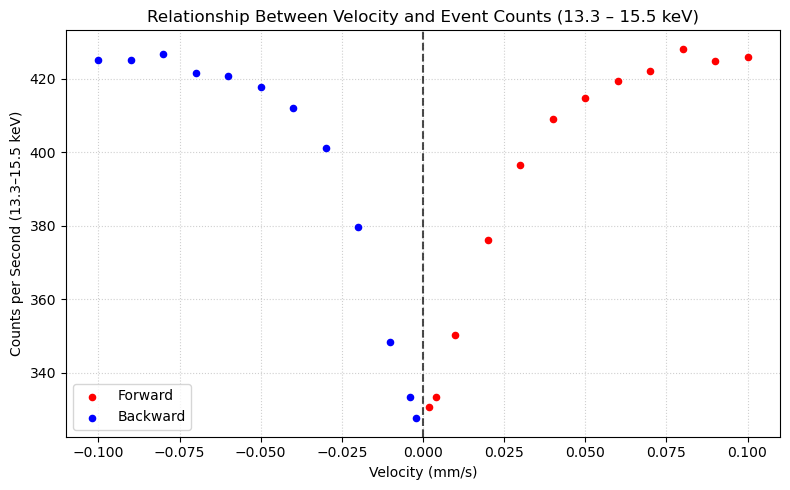

In [139]:
import matplotlib.pyplot as plt
import numpy as np

# Energy window (keV)
e_start = 13.3
e_end = 15.5

fwd_vels, fwd_counts = [], []
bwd_vels, bwd_counts = [], []

for runfile, data in processed_runs.items():
    # try:
    #     vel_raw = float(runfile.split("_")[0])
    #     vel = vel_raw / 1000.0  # Convert integer back to mm/s
    # except ValueError:
    #     print(f"Skipping {runfile}: Cannot parse numerical velocity from name.")
    #     continue
    # print(runfile)
    runfile = float(runfile)
    fwd_chunks = data["forward_energies"]
    bwd_chunks = data["backward_energies"]
    fwd_times = data["forward_times"]
    bwd_times = data["backward_times"]

    # --- Forward Direction ---
    fwd_dur_s = sum((t[-1] - t[0]) for t in fwd_times if len(t) > 1) / 1e6
    if fwd_dur_s > 0 and len(fwd_chunks) > 0:
        fwd_energy_all = np.concatenate(fwd_chunks)
        fwd_kev = adu_to_kev(fwd_energy_all)
        fwd_count = np.sum((fwd_kev >= e_start) & (fwd_kev <= e_end))
        fwd_rate = fwd_count / fwd_dur_s

        if fwd_rate > 0:
            fwd_vels.append(runfile)
            fwd_counts.append(fwd_rate)

    # --- Backward Direction ---
    bwd_dur_s = sum((t[-1] - t[0]) for t in bwd_times if len(t) > 1) / 1e6
    if bwd_dur_s > 0 and len(bwd_chunks) > 0:
        bwd_energy_all = np.concatenate(bwd_chunks)
        bwd_kev = adu_to_kev(bwd_energy_all)
        bwd_count = np.sum((bwd_kev >= e_start) & (bwd_kev <= e_end))
        bwd_rate = bwd_count / bwd_dur_s

        if bwd_rate > 0:
            bwd_vels.append(-runfile)
            bwd_counts.append(bwd_rate)


plt.figure(figsize=(8, 5))

plt.scatter(
    fwd_vels,
    fwd_counts,
    color="red",
    label="Forward",
    marker="o",
    s=20,
    zorder=3,
)
plt.scatter(
    bwd_vels,
    bwd_counts,
    color="blue",
    label="Backward",
    marker="o",
    s=20,
    zorder=3,
)

plt.title(
    f"Relationship Between Velocity and Event Counts ({e_start} – {e_end} keV)"
)
plt.xlabel("Velocity (mm/s)")
plt.ylabel(f"Counts per Second ({e_start}–{e_end} keV)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.axvline(0, linestyle="--", color="black", alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


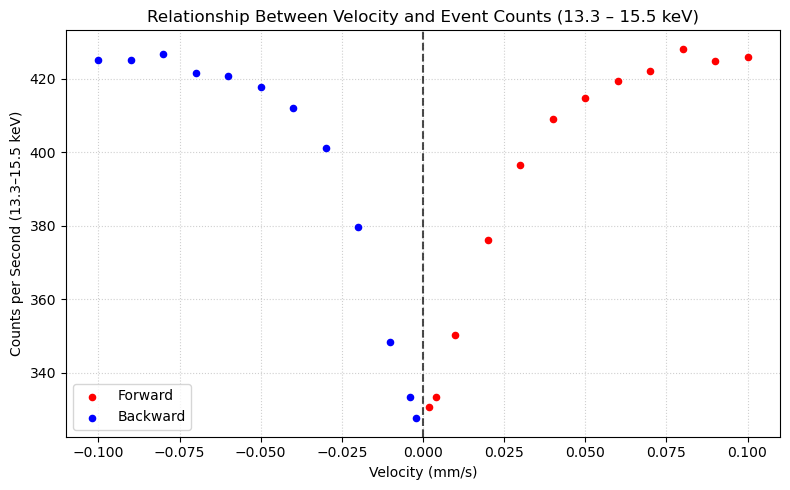

In [140]:
import matplotlib.pyplot as plt
import numpy as np

# Energy window (keV)
e_start = 13.3
e_end = 15.5

fwd_vels, fwd_counts = [], []
bwd_vels, bwd_counts = [], []

for runfile, data in processed_runs.items():

    runfile = float(runfile)
    fwd_chunks = data["forward_energies"]
    bwd_chunks = data["backward_energies"]
    fwd_times = data["forward_times"]
    bwd_times = data["backward_times"]

    # --- Forward Direction ---
    fwd_dur_s = sum((t[-1] - t[0]) for t in fwd_times if len(t) > 1) / 1e6

    if fwd_dur_s > 0 and len(fwd_chunks) > 0:
        fwd_energy_all = np.concatenate(fwd_chunks)
        fwd_kev = adu_to_kev(fwd_energy_all)
        fwd_count = np.sum((fwd_kev >= e_start) & (fwd_kev <= e_end))
        fwd_rate = fwd_count / fwd_dur_s

        if fwd_rate > 0:
            fwd_vels.append(runfile)
            fwd_counts.append(fwd_rate)

    # --- Backward Direction ---
    bwd_dur_s = sum((t[-1] - t[0]) for t in bwd_times if len(t) > 1) / 1e6
    if bwd_dur_s > 0 and len(bwd_chunks) > 0:
        bwd_energy_all = np.concatenate(bwd_chunks)
        bwd_kev = adu_to_kev(bwd_energy_all)
        bwd_count = np.sum((bwd_kev >= e_start) & (bwd_kev <= e_end))
        bwd_rate = bwd_count / bwd_dur_s

        if bwd_rate > 0:
            bwd_vels.append(-runfile)
            bwd_counts.append(bwd_rate)


plt.figure(figsize=(8, 5))

plt.scatter(
    fwd_vels,
    fwd_counts,
    color="red",
    label="Forward",
    marker="o",
    s=20,
    zorder=3,
)
plt.scatter(
    bwd_vels,
    bwd_counts,
    color="blue",
    label="Backward",
    marker="o",
    s=20,
    zorder=3,
)

plt.title(
    f"Relationship Between Velocity and Event Counts ({e_start} – {e_end} keV)"
)
plt.xlabel("Velocity (mm/s)")
plt.ylabel(f"Counts per Second ({e_start}–{e_end} keV)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.axvline(0, linestyle="--", color="black", alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


In [141]:
h_all = {}
adu_all = {}

for label, run in processed_runs.items():
    energy = run["energy"]

    # Define integer ADU bins spanning the min-to-max range
    min_adu = int(np.floor(np.min(energy)))
    max_adu = int(np.ceil(np.max(energy)))
    bins = np.arange(min_adu, max_adu + 2)

    # Compute histogram
    h, b = np.histogram(energy, bins=bins)
    bin_centers = 0.5 * (b[:-1] + b[1:])  # Proper bin centers instead of right edges

    h_all[label] = (h)
    adu_all[label] = (bin_centers)


22551


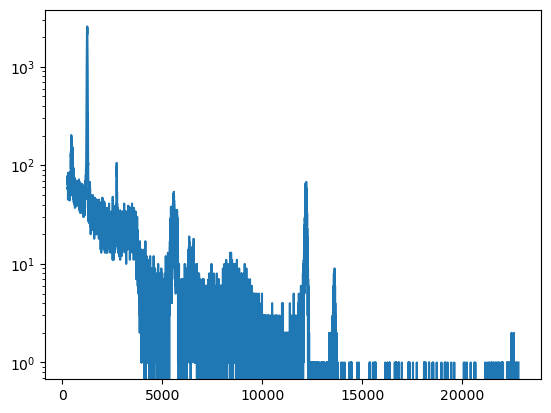

In [142]:
plt.plot(adu_all['0.02'],h_all['0.02'], label ='0.02')

# plt.plot(adu_all[1],h_all[1], alpha =0.3, color = 'red', label = 'With Absorber')

plt.yscale('log')
# plt.xscale('log')
# plt.xlim(kev_to_adu(13),kev_to_adu(16))

##RATE WITH AND WITHOUT ABSORBR
print(len(adu_all['0.02']))